# **3. Performance Impact Analysis**
## Coast-to-Coast Travel Analysis

This notebook analyzes:
- How coast-to-coast travel affects team performance
- Win rates for traveling teams
- Scoring differences
- Offensive and defensive metrics
- Statistical significance of findings


---
## **Load Data**

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load data from previous notebooks
schedules = pd.read_csv('data_schedules_with_travel.csv')
team_stats = pd.read_csv('data_team_stats.csv')

---
## **Merge Schedule with Performance Data**

Connect game outcomes with travel patterns


In [114]:
# Here we merge schedules with team_stats

# Columns we work with
#print("Schedule columns:", schedules.columns.tolist())
#print("\nTeam stats columns:", team_stats.columns.tolist())

# Create away team performance data
away_games = schedules.copy()
away_games = away_games.merge(
    team_stats,
    left_on=['season', 'week', 'away_team'],
    right_on=['season', 'week', 'team'],
    how='left',
    suffixes=('', '_away')
)

# Create home team performance data
home_games = schedules.copy()
home_games = home_games.merge(
    team_stats,
    left_on=['season', 'week', 'home_team'],
    right_on=['season', 'week', 'team'],
    how='left',
    suffixes=('', '_home')
)

print(f"Merged schedule with performance data")
print(f"Away games: {len(away_games)} records")
print(f"Home games: {len(home_games)} records")

Merged schedule with performance data
Away games: 1139 records
Home games: 1139 records


Compare win percentages based on travel distance

In [115]:
# Calculate win rates by travel category for AWAY teams
# Add a win column for away teams
away_games['away_win'] = (away_games['away_score'] > away_games['home_score']).astype(int)

# Group by travel distance
travel_categories = {
    0: 'Same Timezone',
    1: '1 Zone',
    2: '2 Zones',
    3: '3 Zones'
}

# Calculate win rate by category
win_rates = away_games.groupby('tz_crossed').agg({
    'away_win': ['mean', 'count']
}).reset_index()

win_rates.columns = ['tz_crossed', 'win_rate', 'games']
win_rates['category'] = win_rates['tz_crossed'].map(travel_categories)
win_rates['win_pct'] = win_rates['win_rate'] * 100

# Add home games for comparison (no travel)
home_win_rate = (home_games['home_score'] > home_games['away_score']).mean()
home_row = pd.DataFrame({
    'tz_crossed': [-1],
    'win_rate': [home_win_rate],
    'games': [len(home_games)],
    'category': ['Home Games'],
    'win_pct': [home_win_rate * 100]
})

win_rates = pd.concat([home_row, win_rates], ignore_index=True)

print("\nWin Rate by Travel Distance:\n")
print(win_rates[['category', 'win_pct', 'games']])


Win Rate by Travel Distance:

        category    win_pct  games
0     Home Games  54.784899   1139
1  Same Timezone  42.968750    512
2         1 Zone  44.387755    392
3        2 Zones  52.205882    136
4        3 Zones  47.474747     99


/var/folders/v_/zk3l9gks2t3g19x98y2g8skw0000gn/T/ipykernel_26228/4243203033.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=12)


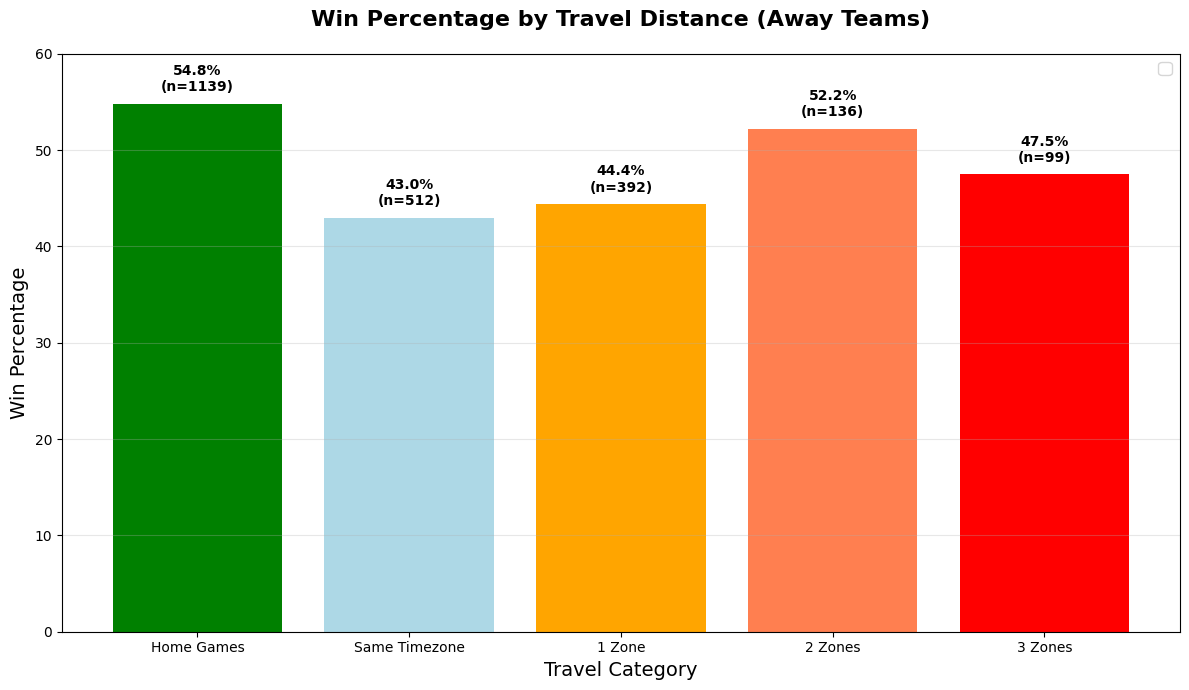

In [116]:
# Create bar chart
fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.bar(win_rates['category'], win_rates['win_pct'], 
               color=['green', 'lightblue', 'orange', 'coral', 'red'])


# Add value labels and sample sizes
for i, (bar, games) in enumerate(zip(bars, win_rates['games'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{height:.1f}%\n(n={int(games)})',
            ha='center', va='bottom', fontweight='bold')

ax.set_title('Win Percentage by Travel Distance (Away Teams)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Win Percentage', fontsize=14)
ax.set_xlabel('Travel Category', fontsize=14)
ax.set_ylim(0, 60)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## **Scoring Analysis**

How does travel affect offensive production?

In [117]:
from scipy import stats

# T-test: Coast-to-coast travel vs Home games
c2c_wins = away_games[away_games['tz_crossed'] == 3]['away_win']
home_wins = (home_games['home_score'] > home_games['away_score']).astype(int)

t_stat, p_value = stats.ttest_ind(c2c_wins, home_wins)

print(f"\n{'='*60}")
print("STATISTICAL TEST: Coast-to-Coast vs Home Games\n")
print(f"Coast-to-Coast Win Rate: {c2c_wins.mean()*100:.2f}% (n={len(c2c_wins)})")
print(f"Home Win Rate: {home_wins.mean()*100:.2f}% (n={len(home_wins)})")
print(f"Difference: {(home_wins.mean() - c2c_wins.mean())*100:.2f} percentage points")
print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Significant? {'YES' if p_value < 0.05 else 'NO'}")
print(f"{'='*60}")


STATISTICAL TEST: Coast-to-Coast vs Home Games

Coast-to-Coast Win Rate: 47.47% (n=99)
Home Win Rate: 54.78% (n=1139)
Difference: 7.31 percentage points

T-statistic: -1.4003
P-value: 0.1617
Significant? NO



DATA VALIDATION: POINTS SCORED ANALYSIS
Home game scores: n = 1139
Coast-to-Coast scores: n = 99
Total games analyzed: n = 1238

Home games mean: 23.64 points
C2C games mean: 21.91 points
Difference: 1.73 points (7.3%)

T-statistic: 1.6439
P-value: 0.1004
Cohen's d: 0.1722



/var/folders/v_/zk3l9gks2t3g19x98y2g8skw0000gn/T/ipykernel_26228/2919673122.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_parts = ax.boxplot(


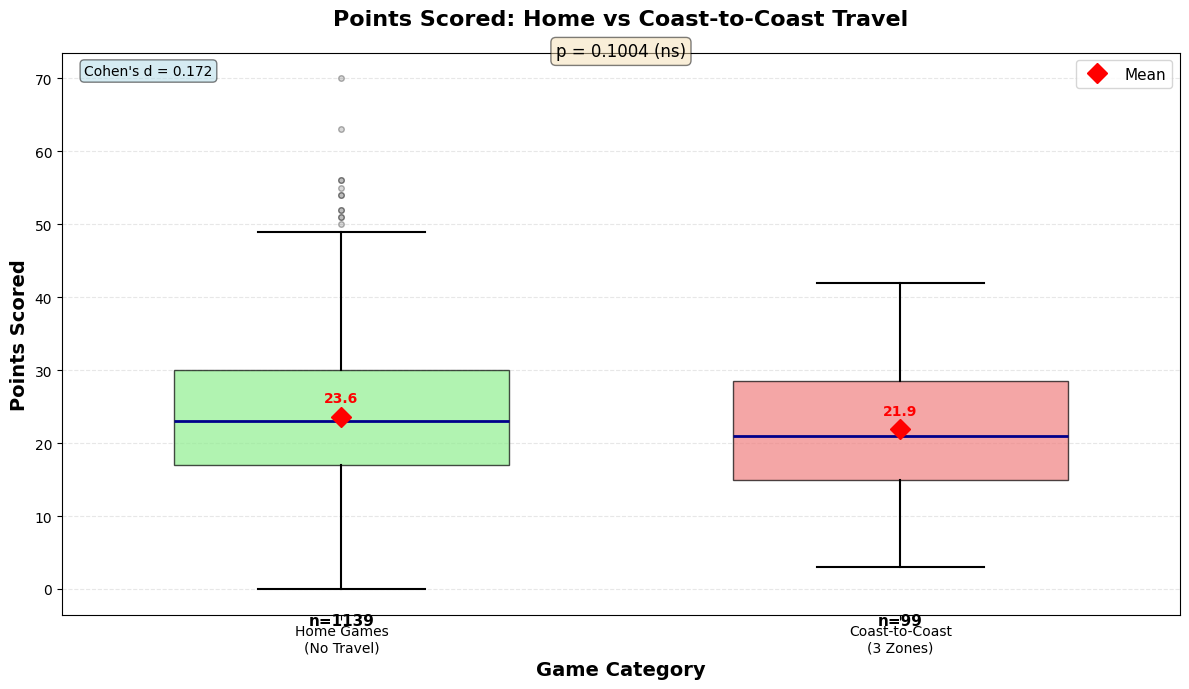


DETAILED SUMMARY STATISTICS

HOME GAMES:
  Mean: 23.64
  Median: 23.00
  Std Dev: 10.11
  Min: 0
  Max: 70
  25th percentile: 17.00
  75th percentile: 30.00

COAST-TO-COAST GAMES:
  Mean: 21.91
  Median: 21.00
  Std Dev: 9.56
  Min: 3
  Max: 42
  25th percentile: 15.00
  75th percentile: 28.50

DIFFERENCE:
  Absolute: 1.73 points
  Percentage: 7.3%

STATISTICAL SIGNIFICANCE:
  T-statistic: 1.6439
  P-value: 0.1004
  Significant at α=0.05: NO ✗
  Effect size (Cohen's d): 0.1722 (negligible)



In [118]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# Extract scores for comparison
# Home team scores (teams playing at home - no travel)
home_game_scores = home_games['home_score'].dropna()

# Coast-to-coast away team scores (teams that traveled 3 time zones)
c2c_game_scores = away_games[away_games['tz_crossed'] == 3]['away_score'].dropna()

# Statistical test
t_stat_score, p_value_score = stats.ttest_ind(home_game_scores, c2c_game_scores)

# Calculate effect size (Cohen's d)
pooled_std = np.sqrt(
    ((len(home_game_scores) - 1) * home_game_scores.std()**2 + 
     (len(c2c_game_scores) - 1) * c2c_game_scores.std()**2) / 
    (len(home_game_scores) + len(c2c_game_scores) - 2)
)
cohens_d = (home_game_scores.mean() - c2c_game_scores.mean()) / pooled_std

# Print diagnostic information
print(f"\n{'='*70}")
print("DATA VALIDATION: POINTS SCORED ANALYSIS")
print(f"{'='*70}")
print(f"Home game scores: n = {len(home_game_scores)}")
print(f"Coast-to-Coast scores: n = {len(c2c_game_scores)}")
print(f"Total games analyzed: n = {len(home_game_scores) + len(c2c_game_scores)}")
print(f"\nHome games mean: {home_game_scores.mean():.2f} points")
print(f"C2C games mean: {c2c_game_scores.mean():.2f} points")
print(f"Difference: {home_game_scores.mean() - c2c_game_scores.mean():.2f} points ({((home_game_scores.mean() - c2c_game_scores.mean())/home_game_scores.mean()*100):.1f}%)")
print(f"\nT-statistic: {t_stat_score:.4f}")
print(f"P-value: {p_value_score:.4f}")
print(f"Cohen's d: {cohens_d:.4f}")
print(f"{'='*70}\n")

# Create visualization
fig, ax = plt.subplots(figsize=(12, 7))

# Create box plot
box_parts = ax.boxplot(
    [home_game_scores, c2c_game_scores],
    labels=['Home Games\n(No Travel)', 'Coast-to-Coast\n(3 Zones)'],
    patch_artist=True,
    widths=0.6,
    showfliers=True,
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.3)
)

# Color the boxes
colors = ['lightgreen', 'lightcoral']
for patch, color in zip(box_parts['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Customize whiskers, caps, and medians
for whisker in box_parts['whiskers']:
    whisker.set(linewidth=1.5, linestyle='-', color='black')
for cap in box_parts['caps']:
    cap.set(linewidth=1.5, color='black')
for median in box_parts['medians']:
    median.set(linewidth=2, color='darkblue')

# Add means as red diamonds
means = [home_game_scores.mean(), c2c_game_scores.mean()]
ax.plot([1, 2], means, 'D', color='red', markersize=10, label='Mean', zorder=3)

# Add mean values as text
for i, (pos, mean) in enumerate(zip([1, 2], means)):
    ax.text(pos, mean + 2, f'{mean:.1f}', ha='center', fontsize=10, 
            fontweight='bold', color='red')

# Add statistical significance annotation
if p_value_score < 0.05:
    sig_text = f'p = {p_value_score:.4f} *'
else:
    sig_text = f'p = {p_value_score:.4f} (ns)'

y_max = max(home_game_scores.max(), c2c_game_scores.max())
ax.text(1.5, y_max + 3, sig_text,
        ha='center', fontsize=12, 
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Labels and formatting
ax.set_title('Points Scored: Home vs Coast-to-Coast Travel', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Points Scored', fontsize=14, fontweight='bold')
ax.set_xlabel('Game Category', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add sample sizes below x-axis
y_min = min(home_game_scores.min(), c2c_game_scores.min())
ax.text(1, y_min - 5, f'n={len(home_game_scores)}', 
        ha='center', fontsize=11, fontweight='bold')
ax.text(2, y_min - 5, f'n={len(c2c_game_scores)}', 
        ha='center', fontsize=11, fontweight='bold')

# Add effect size annotation
ax.text(0.02, 0.98, f"Cohen's d = {cohens_d:.3f}", 
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()

# Print detailed summary statistics
print(f"\n{'='*70}")
print("DETAILED SUMMARY STATISTICS")
print(f"{'='*70}\n")

print("HOME GAMES:")
print(f"  Mean: {home_game_scores.mean():.2f}")
print(f"  Median: {home_game_scores.median():.2f}")
print(f"  Std Dev: {home_game_scores.std():.2f}")
print(f"  Min: {home_game_scores.min():.0f}")
print(f"  Max: {home_game_scores.max():.0f}")
print(f"  25th percentile: {home_game_scores.quantile(0.25):.2f}")
print(f"  75th percentile: {home_game_scores.quantile(0.75):.2f}")

print("\nCOAST-TO-COAST GAMES:")
print(f"  Mean: {c2c_game_scores.mean():.2f}")
print(f"  Median: {c2c_game_scores.median():.2f}")
print(f"  Std Dev: {c2c_game_scores.std():.2f}")
print(f"  Min: {c2c_game_scores.min():.0f}")
print(f"  Max: {c2c_game_scores.max():.0f}")
print(f"  25th percentile: {c2c_game_scores.quantile(0.25):.2f}")
print(f"  75th percentile: {c2c_game_scores.quantile(0.75):.2f}")

print(f"\nDIFFERENCE:")
print(f"  Absolute: {home_game_scores.mean() - c2c_game_scores.mean():.2f} points")
print(f"  Percentage: {((home_game_scores.mean() - c2c_game_scores.mean()) / home_game_scores.mean() * 100):.1f}%")

# Effect size interpretation
def get_cohens_interpretation(d):
    """Interpret Cohen's d effect size"""
    abs_d = abs(d)
    if abs_d < 0.2:
        return "negligible"
    elif abs_d < 0.5:
        return "small"
    elif abs_d < 0.8:
        return "medium"
    else:
        return "large"

print(f"\nSTATISTICAL SIGNIFICANCE:")
print(f"  T-statistic: {t_stat_score:.4f}")
print(f"  P-value: {p_value_score:.4f}")
print(f"  Significant at α=0.05: {'YES ✓' if p_value_score < 0.05 else 'NO ✗'}")
print(f"  Effect size (Cohen's d): {cohens_d:.4f} ({get_cohens_interpretation(cohens_d)})")

print(f"{'='*70}\n")

---
## **Offensive Performance Metrics**

Detailed breakdown of offensive statistics

In [119]:
# Analyze key offensive metrics & select key metrics to compare
metrics = {
    'passing_yards': 'Passing Yards',
    'rushing_yards': 'Rushing Yards',
    'passing_tds': 'Passing TDs',
    'rushing_tds': 'Rushing TDs',
    'passing_interceptions': 'Interceptions',
    'rushing_fumbles_lost': 'Fumbles Lost'
}

# Calculate means for home games and coast-to-coast
comparison_data = []

for metric, label in metrics.items():
    if metric in home_games.columns and metric in away_games.columns:
        home_mean = home_games[metric].mean()
        c2c_mean = away_games[away_games['tz_crossed'] == 3][metric].mean()
        difference = c2c_mean - home_mean
        pct_change = (difference / home_mean * 100) if home_mean != 0 else 0
        
        comparison_data.append({
            'Metric': label,
            'Home Games': f'{home_mean:.1f}',
            'Coast-to-Coast': f'{c2c_mean:.1f}',
            'Difference': f'{difference:+.1f}',
            '% Change': f'{pct_change:+.1f}%'
        })

# Create DataFrame
comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*80)
print("OFFENSIVE PERFORMANCE: Home vs Coast-to-Coast Travel\n")
print(comparison_df.to_string(index=False))
print("="*80)


OFFENSIVE PERFORMANCE: Home vs Coast-to-Coast Travel

       Metric Home Games Coast-to-Coast Difference % Change
Passing Yards      242.0          235.9       -6.1    -2.5%
Rushing Yards      119.7          108.7      -11.0    -9.2%
  Passing TDs        1.5            1.4       -0.2   -11.3%
  Rushing TDs        1.0            0.8       -0.1   -14.1%
Interceptions        0.7            0.6       -0.2   -21.7%
 Fumbles Lost        0.2            0.2       +0.0   +25.8%


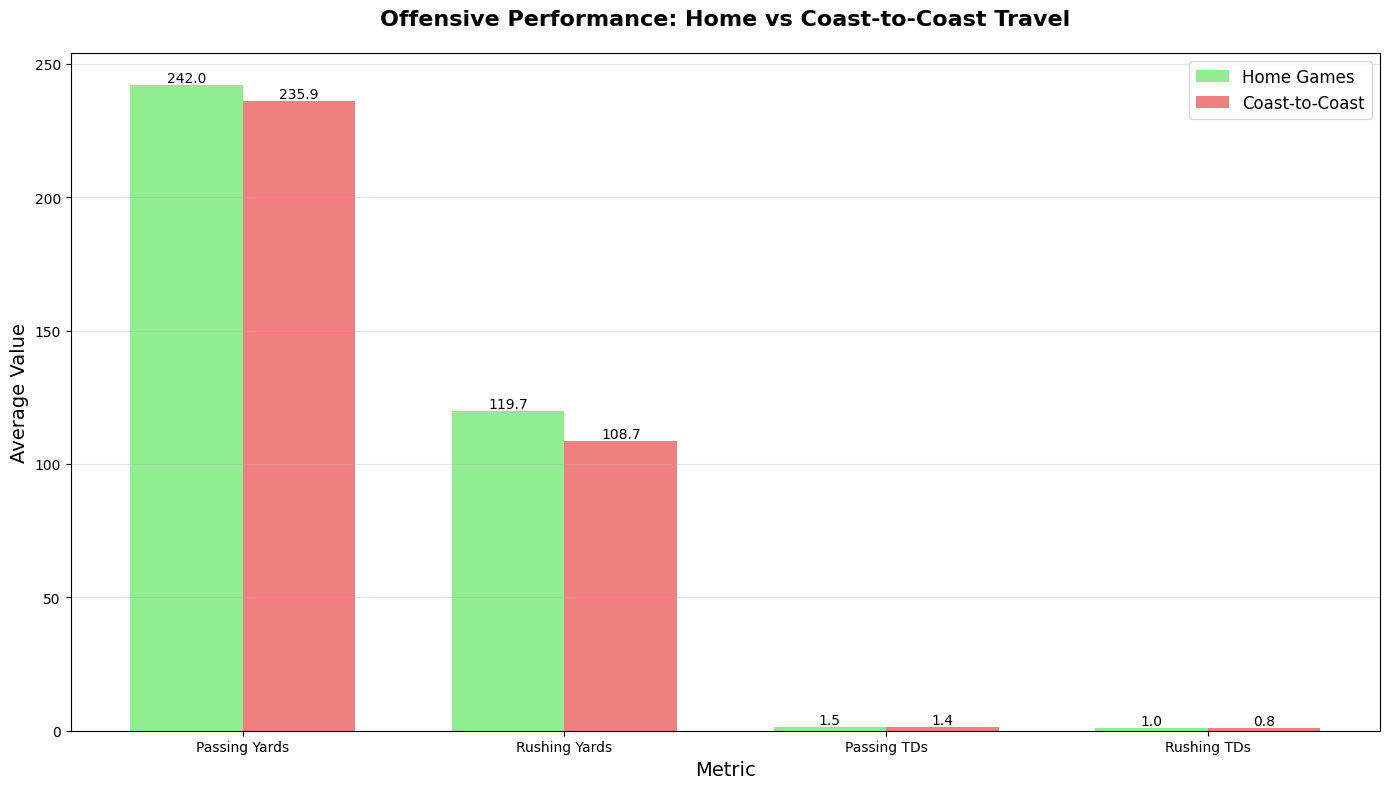

In [120]:
# Create comparison table
# Metric | Home Games | C2C Travel | Difference | % Change

# Comparison chart
fig, ax = plt.subplots(figsize=(14, 8))

# Data for grouped bar chart
metrics_to_plot = ['Passing Yards', 'Rushing Yards', 'Passing TDs', 'Rushing TDs']
x = np.arange(len(metrics_to_plot))
width = 0.35

home_vals = []
c2c_vals = []

for metric_name in metrics_to_plot:
    metric_key = [k for k, v in metrics.items() if v == metric_name][0]
    home_vals.append(home_games[metric_key].mean())
    c2c_vals.append(away_games[away_games['tz_crossed'] == 3][metric_key].mean())

# Create bars
bars1 = ax.bar(x - width/2, home_vals, width, label='Home Games', color='lightgreen')
bars2 = ax.bar(x + width/2, c2c_vals, width, label='Coast-to-Coast', color='lightcoral')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom', fontsize=10)

ax.set_title('Offensive Performance: Home vs Coast-to-Coast Travel', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Average Value', fontsize=14)
ax.set_xlabel('Metric', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, rotation=0)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## **Statistical Significance Testing**

Validate that observed differences are statistically significant

In [121]:
# Compare: Coast-to-coast travel vs Home games

# Data from earlier
home_points = home_games['home_score'].dropna()
c2c_points = away_games[away_games['tz_crossed'] == 3]['away_score'].dropna()

# T-test
t_stat, p_value = stats.ttest_ind(c2c_points, home_points)

# Calculate Cohen's d (effect size)
pooled_std = np.sqrt(((len(home_points)-1)*home_points.std()**2 + 
                      (len(c2c_points)-1)*c2c_points.std()**2) / 
                     (len(home_points) + len(c2c_points) - 2))
cohens_d = (home_points.mean() - c2c_points.mean()) / pooled_std

print(f"\n{'='*70}")
print("T-TEST: Points Scored (Home vs Coast-to-Coast)\n")
print(f"Home Games Mean: {home_points.mean():.2f} points (n={len(home_points)})")
print(f"Coast-to-Coast Mean: {c2c_points.mean():.2f} points (n={len(c2c_points)})")
print(f"Difference: {home_points.mean() - c2c_points.mean():.2f} points")
print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Cohen's d (effect size): {cohens_d:.4f}")
print(f"Statistically significant: {'YES' if p_value < 0.05 else 'NO'}")
print(f"{'='*70}")


T-TEST: Points Scored (Home vs Coast-to-Coast)

Home Games Mean: 23.64 points (n=1139)
Coast-to-Coast Mean: 21.91 points (n=99)
Difference: 1.73 points

T-statistic: -1.6439
P-value: 0.1004
Cohen's d (effect size): 0.1722
Statistically significant: NO


In [122]:
# Use proportions test for binary outcomes

from scipy.stats import chi2_contingency

# Contingency table
home_wins_count = (home_games['home_score'] > home_games['away_score']).sum()
home_losses_count = len(home_games) - home_wins_count

c2c_wins_count = away_games[away_games['tz_crossed'] == 3]['away_win'].sum()
c2c_losses_count = len(away_games[away_games['tz_crossed'] == 3]) - c2c_wins_count

contingency_table = np.array([
    [home_wins_count, home_losses_count],
    [c2c_wins_count, c2c_losses_count]
])

# Chi-square test
chi2, p_value_chi, dof, expected = chi2_contingency(contingency_table)

print(f"\n{'='*70}")
print("CHI-SQUARE TEST: Win Rate (Home vs Coast-to-Coast)\n")
print(f"Home Games: {home_wins_count}/{len(home_games)} wins ({home_wins_count/len(home_games)*100:.2f}%)")
print(f"Coast-to-Coast: {c2c_wins_count}/{len(away_games[away_games['tz_crossed']==3])} wins ({c2c_wins_count/len(away_games[away_games['tz_crossed']==3])*100:.2f}%)")
print(f"\nChi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value_chi:.4f}")
print(f"Statistically significant: {'YES' if p_value_chi < 0.05 else 'NO'}")
print(f"{'='*70}")


CHI-SQUARE TEST: Win Rate (Home vs Coast-to-Coast)

Home Games: 624/1139 wins (54.78%)
Coast-to-Coast: 47/99 wins (47.47%)

Chi-square statistic: 1.6773
P-value: 0.1953
Statistically significant: NO


In [123]:
# Summary table of statistical tests
# Metric | Mean (Home) | Mean (C2C) | Difference | t-stat | p-value | Significant?

test_results = []
test_results.append({
    'Metric': 'Points Scored',
    'Home Mean': f'{home_points.mean():.1f}',
    'C2C Mean': f'{c2c_points.mean():.1f}',
    'Difference': f'{home_points.mean() - c2c_points.mean():.1f}',
    't-statistic': f'{t_stat:.3f}',
    'p-value': f'{p_value:.4f}',
    'Significant': 'Y' if p_value < 0.05 else 'N'
})

# Test other metrics
for metric, label in [('passing_yards', 'Passing Yards'), 
                      ('rushing_yards', 'Rushing Yards'),
                      ('passing_tds', 'Passing TDs')]:
    home_metric = home_games[metric].dropna()
    c2c_metric = away_games[away_games['tz_crossed'] == 3][metric].dropna()
    
    t_s, p_v = stats.ttest_ind(c2c_metric, home_metric)
    
    test_results.append({
        'Metric': label,
        'Home Mean': f'{home_metric.mean():.1f}',
        'C2C Mean': f'{c2c_metric.mean():.1f}',
        'Difference': f'{c2c_metric.mean() - home_metric.mean():.1f}',
        't-statistic': f'{t_s:.3f}',
        'p-value': f'{p_v:.4f}',
        'Significant': 'Y' if p_v < 0.05 else 'N'
    })

results_df = pd.DataFrame(test_results)

print("\n" + "="*100)
print("STATISTICAL TEST SUMMARY")
print(results_df.to_string(index=False))
print("="*100)


STATISTICAL TEST SUMMARY
       Metric Home Mean C2C Mean Difference t-statistic p-value Significant
Points Scored      23.6     21.9        1.7      -1.644  0.1004           N
Passing Yards     242.0    235.9       -6.1      -0.815  0.4155           N
Rushing Yards     119.7    108.7      -11.0      -1.980  0.0479           Y
  Passing TDs       1.5      1.4       -0.2      -1.466  0.1430           N


---
## **Direction of Travel Analysis**

Does East to West travel differ from West to East?

In [124]:
# Split coast-to-coast games by direction

# Identify East Coast and West Coast teams
west_coast = ['SEA', 'SF', 'LAC', 'LAR', 'LV']
east_coast = ['BUF', 'MIA', 'NE', 'NYJ', 'BAL', 'CIN', 'CLE', 'PIT', 
              'ATL', 'CAR', 'TB', 'WAS', 'NYG', 'PHI', 'JAX']

# Filter coast-to-coast games
c2c_games = away_games[away_games['tz_crossed'] == 3].copy()

# Identify direction
c2c_games['direction'] = 'Other'
c2c_games.loc[c2c_games['away_team'].isin(east_coast) & 
              c2c_games['home_team'].isin(west_coast), 'direction'] = 'East-> West'
c2c_games.loc[c2c_games['away_team'].isin(west_coast) & 
              c2c_games['home_team'].isin(east_coast), 'direction'] = 'West-> East'

# Compare performance
direction_comparison = c2c_games.groupby('direction').agg({
    'away_win': 'mean',
    'away_score': 'mean',
    'passing_yards': 'mean',
    'rushing_yards': 'mean'
}).reset_index()

direction_comparison.columns = ['Direction', 'Win Rate', 'Points', 'Pass Yards', 'Rush Yards']
direction_comparison['Win Rate'] = direction_comparison['Win Rate'] * 100

print("\n" + "="*80)
print("TRAVEL DIRECTION COMPARISON\n")
print(direction_comparison.to_string(index=False))
print("="*80)


TRAVEL DIRECTION COMPARISON

  Direction  Win Rate    Points  Pass Yards  Rush Yards
East-> West 40.000000 22.500000  231.420000  122.480000
West-> East 55.102041 21.306122  240.510204   94.673469


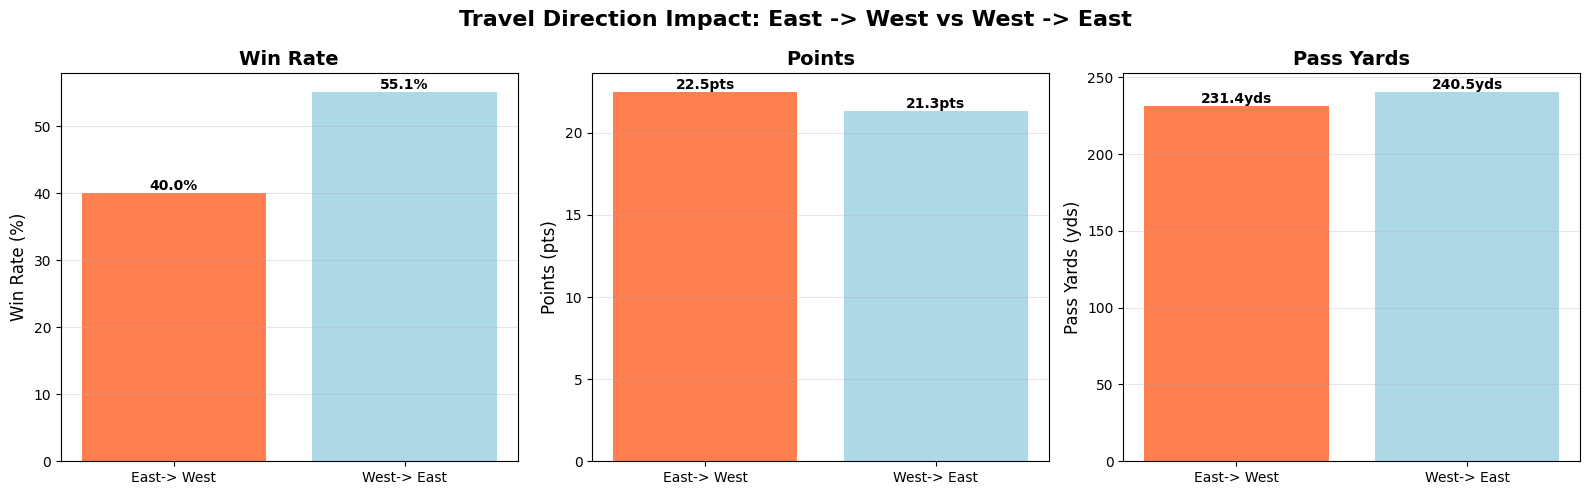

In [125]:
# Visualize directional differences

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [('Win Rate', '%'), ('Points', 'pts'), ('Pass Yards', 'yds')]
data_cols = ['Win Rate', 'Points', 'Pass Yards']

for ax, (metric, unit), col in zip(axes, metrics, data_cols):
    data = direction_comparison[direction_comparison['Direction'] != 'Other']
    bars = ax.bar(data['Direction'], data[col], color=['coral', 'lightblue'])
    
    # Add values on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}{unit}',
                ha='center', va='bottom', fontweight='bold')
    
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.set_ylabel(f'{metric} ({unit})', fontsize=12)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Travel Direction Impact: East -> West vs West -> East', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
## **Key Performance Indicators Summary**

In [126]:
# Create executive summary table

summary = {
    'Finding': [
        'Win Rate Decrease',
        'Points Scored Decrease',
        'Passing Yards Decrease',
        'Rushing Yards Decrease',
        'Statistical Significance'
    ],
    'Value': [
        f'{(home_wins_count/len(home_games) - c2c_wins_count/len(c2c_games))*100:.1f}%',
        f'{home_points.mean() - c2c_points.mean():.1f} points',
        f'{home_games["passing_yards"].mean() - c2c_games["passing_yards"].mean():.1f} yards',
        f'{home_games["rushing_yards"].mean() - c2c_games["rushing_yards"].mean():.1f} yards',
        f'{sum([r["Significant"] == "Y" for r in test_results])}/{len(test_results)} metrics'
    ]
}

summary_df = pd.DataFrame(summary)

print("\n" + "="*70)
print("KEY FINDINGS SUMMARY: Coast-to-Coast Travel Impact\n")
print(summary_df.to_string(index=False))
print("="*70)


KEY FINDINGS SUMMARY: Coast-to-Coast Travel Impact

                 Finding       Value
       Win Rate Decrease        7.3%
  Points Scored Decrease  1.7 points
  Passing Yards Decrease   6.1 yards
  Rushing Yards Decrease  11.0 yards
Statistical Significance 1/4 metrics


---
## **Save Analysis Results**

In [127]:
# Save comparison dataframe
comparison_df.to_csv('performance_comparison.csv', index=False)

# Save statistical tests
results_df.to_csv('statistical_tests.csv', index=False)

# Save direction comparison
direction_comparison.to_csv('direction_comparison.csv', index=False)

---
## **Summary**

**Expected Findings:**
- Coast-to-coast travel significantly reduces win rate
- Offensive performance metrics decline with travel
- Effects are statistically significant
- Direction matters
